In [1]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Carga desde un archivo .csv sin indice
data = pd.read_csv('Ventas_Plaza_Mensual_Limpia.csv') 

In [3]:
#Verificamos información del DataFrame
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 31 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Plazas          9 non-null      str    
 1   Febrero, 24     3 non-null      float64
 2   Marzo, 24       4 non-null      float64
 3   Abril, 24       6 non-null      float64
 4   Mayo, 24        7 non-null      float64
 5   Junio, 24       7 non-null      float64
 6   Julio, 24       7 non-null      float64
 7   Agosto, 24      7 non-null      float64
 8   Septiembre, 24  7 non-null      float64
 9   Octubre, 24     7 non-null      float64
 10  Noviembre, 24   7 non-null      float64
 11  Diciembre, 24   8 non-null      float64
 12  Enero, 25       8 non-null      float64
 13  Febrero, 25     8 non-null      float64
 14  Marzo, 25       8 non-null      float64
 15  Abril, 25       8 non-null      float64
 16  Mayo, 25        8 non-null      float64
 17  Junio, 25       8 non-null      float64
 18  Jul

Debido a la forma del dataset, los outliers al sacarse por columna, pero cada fila siendo una variable. Se decide normalizar la base de datos a un formato tidy.

In [8]:
df_tidy = data.set_index('Plazas ').T.reset_index()

df_tidy = df_tidy.rename(columns={
    'index': 'Fecha'
})

In [9]:
df_tidy.head()

Plazas,Fecha,Leads,Efectivos,SDC,PDM,Citas Programadas,NaN,Citas Efectivas,NaN,Ventas,Conversion,Aporte
0,"Febrero, 24",0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN
1,"Marzo, 24",0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
2,"Abril, 24",25.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,0.0,0.0,0.0
3,"Mayo, 24",28.0,NaN,NaN,11.0,3.0,NaN,2.0,NaN,0.0,0.0,0.0
4,"Junio, 24",68.0,NaN,NaN,5.0,2.0,NaN,2.0,NaN,0.0,0.0,0.0


In [ ]:
#Eliminar columas creadas por el proceso de transposición que se llaman NaN
df = df_tidy.drop(columns=[col for col in df_tidy.columns if pd.isna(col)])

In [12]:
df.head()

Plazas,Fecha,Leads,Efectivos,SDC,PDM,Citas Programadas,Citas Efectivas,Ventas,Conversion,Aporte
0,"Febrero, 24",0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN
1,"Marzo, 24",0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
2,"Abril, 24",25.0,NaN,NaN,1.0,1.0,NaN,0.0,0.0,0.0
3,"Mayo, 24",28.0,NaN,NaN,11.0,3.0,2.0,0.0,0.0,0.0
4,"Junio, 24",68.0,NaN,NaN,5.0,2.0,2.0,0.0,0.0,0.0


División de las columnas cualitativas y cuantitativas para la búsqueda de los outlier

In [16]:
#Creo 2 dataframe para poder procesar los outliers, separando las variables cualitativas de las cuantitativas
cualitativas = df['Fecha']
cuantitativas = df.iloc[:, 1:11]

In [17]:
#Se corroboran los dataframes creados
cualitativas.head()

0    Febrero, 24
1      Marzo, 24
2      Abril, 24
3       Mayo, 24
4      Junio, 24
Name: Fecha, dtype: str

In [18]:
#Se corroboran los dataframes creados
cuantitativas.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Leads               30 non-null     float64
 1   Efectivos           12 non-null     float64
 2   SDC                 20 non-null     float64
 3   PDM                 28 non-null     float64
 4   Citas Programadas   28 non-null     float64
 5   Citas Efectivas     27 non-null     float64
 6   Ventas              30 non-null     float64
 7   Conversion          30 non-null     float64
 8   Aporte              29 non-null     float64
dtypes: float64(9)
memory usage: 2.2 KB


Identificamos outliers

<Figure size 1500x800 with 0 Axes>

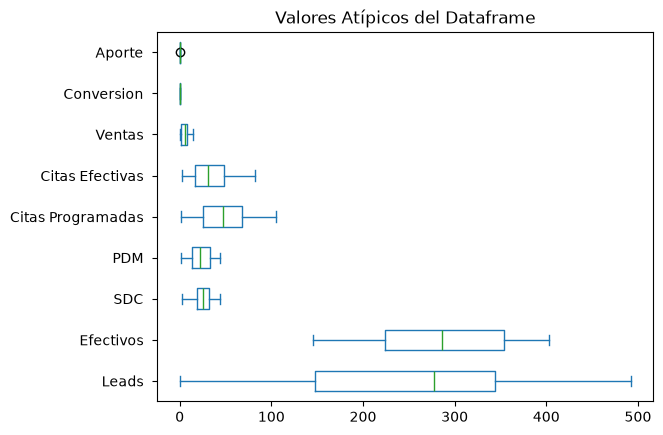

In [19]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize =(15, 8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show() #dibujamos el diagrama

In [20]:
#Método aplicando Cuartiles. Encuentro cuartiles 0.25 y 0.75
y=cuantitativas

percentile25=y.quantile(0.25) #Q1
percentile75=y.quantile(0.75) #Q3
iqr= percentile75 - percentile25

Limite_Superior_iqr= percentile75 + 1.5*iqr
Limite_Inferior_iqr= percentile25 - 1.5*iqr
print("Limite superior permitido", Limite_Superior_iqr)
print("Limite inferior permitido", Limite_Inferior_iqr)

Limite superior permitido Plazas 
Leads                 640.375000
Efectivos             549.625000
SDC                    51.250000
PDM                    63.500000
Citas Programadas     133.375000
Citas Efectivas        96.500000
Ventas                 17.500000
Conversion              0.055220
Aporte                  0.511029
dtype: float64
Limite inferior permitido Plazas 
Leads                -148.625000
Efectivos              28.625000
SDC                    -0.750000
PDM                   -16.500000
Citas Programadas     -39.625000
Citas Efectivas       -31.500000
Ventas                 -8.500000
Conversion             -0.022210
Aporte                 -0.118382
dtype: float64


In [21]:
#Obtenemos datos limpios del Dataframe
data1_iqr= cuantitativas[(y<=Limite_Superior_iqr)&(y>=Limite_Inferior_iqr)]
data1_iqr.head()

Plazas,Leads,Efectivos,SDC,PDM,Citas Programadas,Citas Efectivas,Ventas,Conversion,Aporte
0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN
1,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
2,25.0,NaN,NaN,1.0,1.0,NaN,0.0,0.0,0.0
3,28.0,NaN,NaN,11.0,3.0,2.0,0.0,0.0,0.0
4,68.0,NaN,NaN,5.0,2.0,2.0,0.0,0.0,0.0


In [22]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data1_iqr.isnull().sum()
valores_nulos

Plazas 
Leads                  0
Efectivos             18
SDC                   10
PDM                    2
Citas Programadas      2
Citas Efectivas        3
Ventas                 0
Conversion             0
Aporte                 2
dtype: int64

In [23]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data2_iqr=data1_iqr.copy()
data2_iqr=data2_iqr.fillna(round(data1_iqr.median(),1))
data2_iqr.head()

Plazas,Leads,Efectivos,SDC,PDM,Citas Programadas,Citas Efectivas,Ventas,Conversion,Aporte
0,0.0,286.0,25.0,22.5,47.0,31.0,0.0,0.0,0.2
1,0.0,286.0,25.0,22.5,47.0,31.0,0.0,0.0,0.0
2,25.0,286.0,25.0,1.0,1.0,31.0,0.0,0.0,0.0
3,28.0,286.0,25.0,11.0,3.0,2.0,0.0,0.0,0.0
4,68.0,286.0,25.0,5.0,2.0,2.0,0.0,0.0,0.0


In [24]:
# Unimos el dataframe cuantitativo limpio con el dataframe cualitativo

Datos_limpios = pd.concat([cualitativas, data2_iqr], axis=1)
Datos_limpios.head()

,Fecha,Leads,Efectivos,SDC,PDM,Citas Programadas,Citas Efectivas,Ventas,Conversion,Aporte
0,"Febrero, 24",0.0,286.0,25.0,22.5,47.0,31.0,0.0,0.0,0.2
1,"Marzo, 24",0.0,286.0,25.0,22.5,47.0,31.0,0.0,0.0,0.0
2,"Abril, 24",25.0,286.0,25.0,1.0,1.0,31.0,0.0,0.0,0.0
3,"Mayo, 24",28.0,286.0,25.0,11.0,3.0,2.0,0.0,0.0,0.0
4,"Junio, 24",68.0,286.0,25.0,5.0,2.0,2.0,0.0,0.0,0.0


In [25]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=Datos_limpios.isnull().sum()
valores_nulos

Fecha                 0
Leads                 0
Efectivos             0
SDC                   0
PDM                   0
Citas Programadas     0
Citas Efectivas       0
Ventas                0
Conversion            0
Aporte                0
dtype: int64

In [26]:
#Convertir DataFrame a CSV
Datos_limpios.to_csv("Ventas_Plaza_Mensual_sin_outliers.csv")